<a href="https://colab.research.google.com/github/AlyssonBatista/Reader-and-grader-of-multiple-choice-tests./blob/main/Answer_Sheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install imutils

## Exemplo [Leitor e corretor de provas de múltipla escolha com folhas de respostas usando OMR, Python e OpenCV.](https://pyimagesearch.com/2016/10/03/bubble-sheet-multiple-choice-scanner-and-test-grader-using-omr-python-and-opencv/)

In [86]:
from google.colab import files
uploaded = files.upload()

Saving feito no gpt.png to feito no gpt (1).png


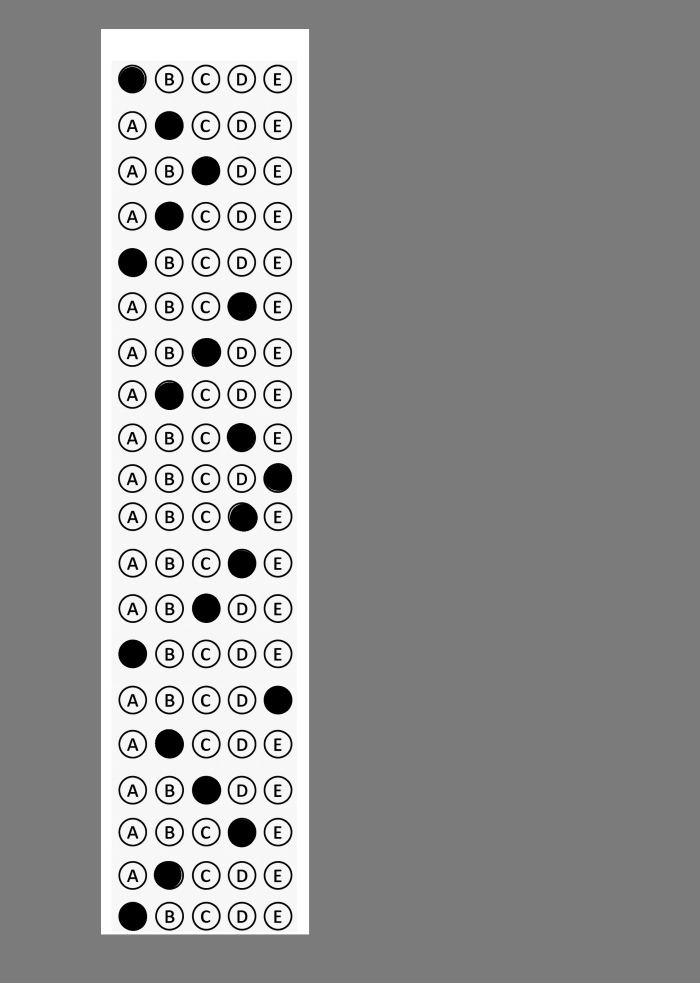

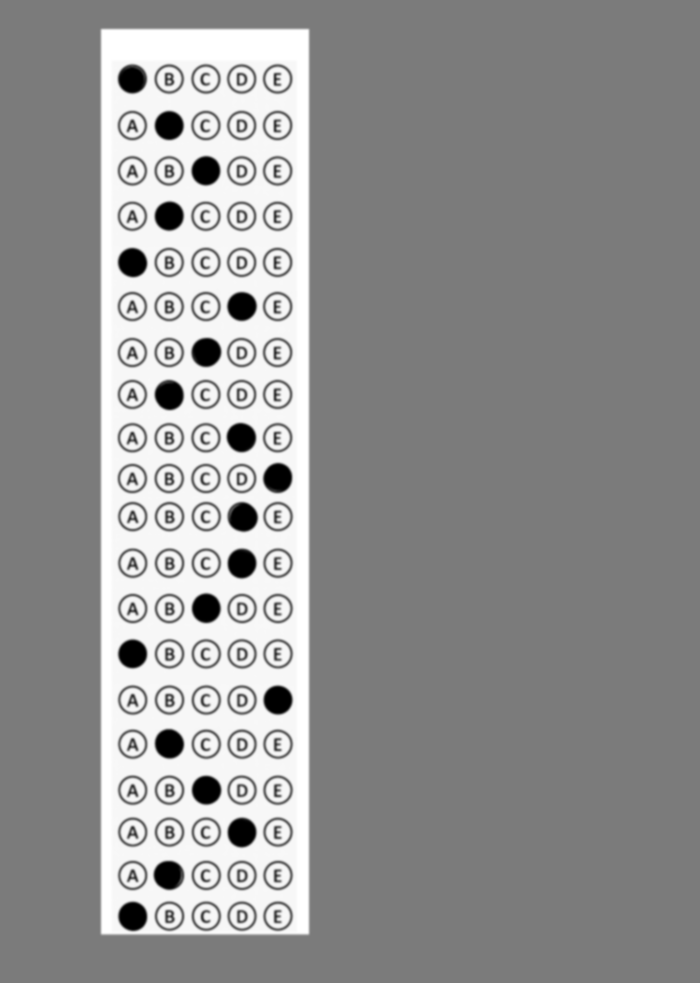

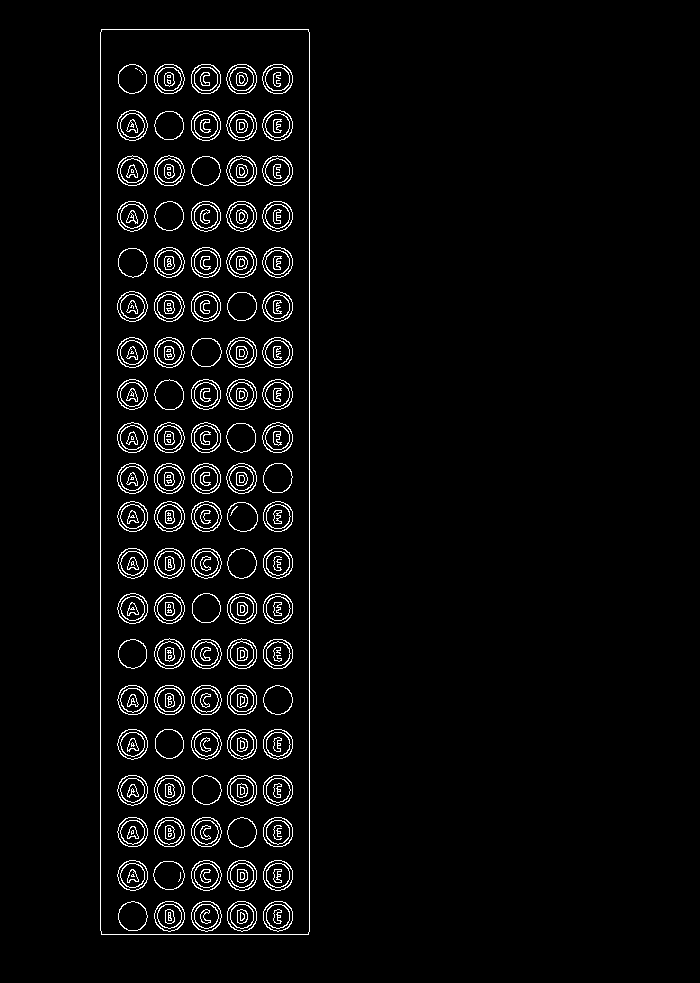

In [87]:
# ============================
# IMPORTAÇÕES NECESSÁRIAS
# ============================
# four_point_transform → utilizado mais tarde para "achatar" (retificar) o cartão de resposta
from imutils.perspective import four_point_transform
# contours → usado para ordenar contornos (da esquerda/direita, cima/baixo)
from imutils import contours
import numpy as np
import imutils
import cv2

# Biblioteca necessária para mostrar imagens no Google Colab
from google.colab.patches import cv2_imshow


# ============================
# CARREGAR A IMAGEM ENVIADA
# ============================
# "uploaded" é criado pelo comando files.upload() anteriormente no notebook.
# Ele guarda os arquivos enviados pelo usuário no Colab.
filename = list(uploaded.keys())[0]

# Carrega a imagem com OpenCV
# OBS: O OpenCV lê imagens no formato BGR (não RGB)
image = cv2.imread(filename)


# ============================
# PRÉ-PROCESSAMENTO INICIAL
# ============================
# Redimensiona a imagem para facilitar o processamento.
# Isso ajuda os algoritmos a rodarem mais rápido e com mais consistência.
image = imutils.resize(image, width=700)


# ----------------------------
# 1. Converter a imagem para escala de cinza
# ----------------------------
# Processar em tons de cinza deixa mais rápido e reduz ruído.
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ----------------------------
# 2. Aplicar desfoque (blur)
# ----------------------------
# Reduz detalhes desnecessários e facilita a detecção das bordas.
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# ----------------------------
# 3. Detectar bordas (Canny)
# ----------------------------
# Identifica contornos fortes, que ajudarão a encontrar o cartão resposta.
edged = cv2.Canny(blurred, 75, 200)


# ============================
# EXIBIR AS ETAPAS
# ============================
cv2_imshow(gray)     # imagem em escala de cinza
cv2_imshow(blurred)  # imagem borrada
cv2_imshow(edged)    # imagem com detecção de bordas


In [88]:
# ============================
# ENCONTRAR O CONTORNO DO CARTÃO-RESPOSTA
# ============================

# 1. Encontrar contornos na imagem de bordas (edged)
#    - cv2.RETR_EXTERNAL → pega apenas os contornos externos (mais limpo)
#    - cv2.CHAIN_APPROX_SIMPLE → reduz pontos desnecessários no contorno
cnts = cv2.findContours(
    edged.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# O OpenCV retorna diferentes quantidades dependendo da versão,
# imutils.grab_contours resolve isso automaticamente.
cnts = imutils.grab_contours(cnts)

# Ordena os contornos pelo tamanho da área (maiores primeiro)
# Isso funciona porque o cartão normalmente é o maior retângulo da imagem.
cnts = sorted(cnts, key=cv2.contourArea, reverse=True)


# Variável que irá guardar o contorno final do cartão
docCnt = None


# 2. Percorrer os contornos em ordem decrescente de área
for c in cnts:

    # Calcula o perímetro do contorno
    peri = cv2.arcLength(c, True)

    # Aproxima o contorno para uma forma mais simples usando
    # o algoritmo de Douglas-Peucker.
    # 0.02 * peri controla a precisão (ajusta o nível de "simplificação").
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)

    # 3. Identificar um contorno com *exatamente 4 pontos*
    #    Isso indica que provavelmente é um retângulo (o cartão).
    if len(approx) == 4:
        docCnt = approx
        break  # já encontramos o cartão, podemos parar


# Agora "docCnt" contém o contorno do cartão ou None se nada foi encontrado.



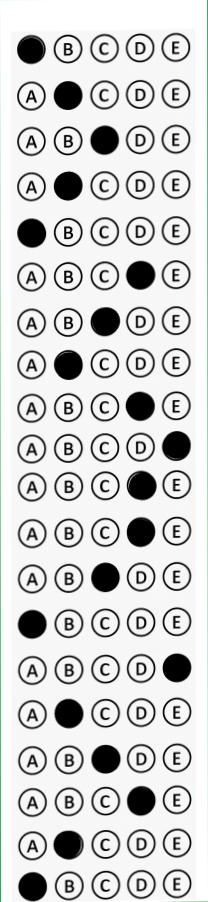

In [89]:
# ============================
# TRANSFORMAÇÃO DE PERSPECTIVA (RETIFICAR O CARTÃO)
# ============================

# O 'docCnt' contém os 4 pontos do cartão detectado.
# Aqui convertemos os pontos para uma matriz 4x2.
pts = docCnt.reshape(4, 2)

# "paper" = cartão retificado em QUALIDADE COLORIDA (BGR)
paper = four_point_transform(image, pts)

# "warped" = versão retificada em escala de cinza (útil para processamento)
warped = four_point_transform(gray, pts)

# Mostrar o cartão retificado
cv2_imshow(paper)


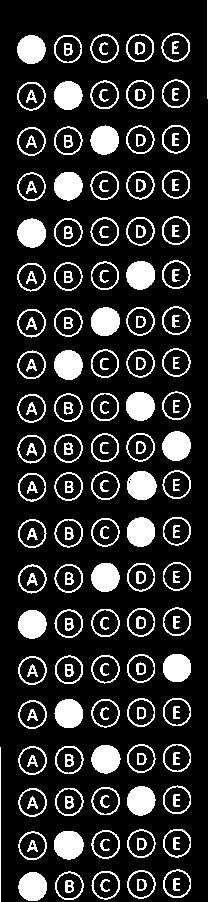

In [90]:
# ============================
# BINARIZAÇÃO (THRESHOLD) PARA DESTACAR BOLHAS
# ============================

# THRESH_BINARY_INV → bolhas ficam brancas
# OTSU → define o melhor valor de threshold automaticamente
thresh = cv2.threshold(
    warped,
    0,
    255,
    cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU
)[1]

# Mostrar imagem binarizada
cv2_imshow(thresh)



In [91]:
# ============================
# DETECÇÃO DAS BOLHAS DAS QUESTÕES
# ============================

# Encontrar contornos brancos na imagem binarizada
cnts = cv2.findContours(
    thresh.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
cnts = imutils.grab_contours(cnts)

questionCnts = []  # lista final com bolhas válidas

for c in cnts:
    # Obter a caixa delimitadora do contorno
    x, y, w, h = cv2.boundingRect(c)

    # Relação de aspecto → ajuda a garantir que é uma forma QUASE circular
    ar = w / float(h)

    # Filtros para garantir que o contorno é uma bolha
    # - tamanho mínimo (20x20 px)
    # - quase quadrado (ar entre 0.9 e 1.1)
    if w >= 20 and h >= 20 and 0.9 <= ar <= 1.1:
        questionCnts.append(c)

print("Bolhas detectadas:", len(questionCnts))


Bolhas detectadas: 100


In [92]:
# Ordena de cima para baixo para garantir que a leitura das questões fique correta
questionCnts = contours.sort_contours(questionCnts, method="top-to-bottom")[0]


In [93]:
# gabarito da prova

ANSWER_KEY_LETTERS = ["B","E","A","C","B","A","C","E","A","A","B","E","A","C","B","A","C","E","A","A"]
ANSWER_KEY = {i: "ABCDE".index(a) for i, a in enumerate(ANSWER_KEY_LETTERS)}


Total de acertos: 3


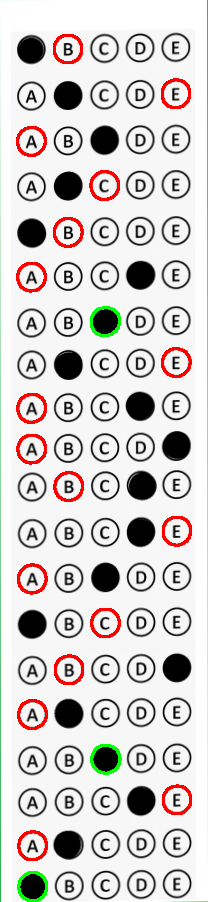

In [94]:
# correct = 0

# # Cada questão possui 5 alternativas
# NUM_ALTERNATIVAS = 5

# for (q, i) in enumerate(range(0, len(questionCnts), NUM_ALTERNATIVAS)):
#     cnts = contours.sort_contours(questionCnts[i:i + NUM_ALTERNATIVAS])[0]
#     bubbled = None

#     for (j, c) in enumerate(cnts):
#         mask = np.zeros(thresh.shape, dtype="uint8")
#         cv2.drawContours(mask, [c], -1, 255, -1)

#         mask = cv2.bitwise_and(thresh, thresh, mask=mask)
#         total = cv2.countNonZero(mask)

#         if bubbled is None or total > bubbled[0]:
#             bubbled = (total, j)

#     color = (0, 0, 255)
#     k = ANSWER_KEY[q]

#     if k == bubbled[1]:
#         color = (0, 255, 0)
#         correct += 1

#     cv2.drawContours(paper, [cnts[k]], -1, color, 2)

# cv2_imshow(paper)

# ======================================================================================================

correct = 0                   # contador de acertos
NUM_ALTERNATIVAS = 5          # A B C D E

# Percorre de 5 em 5 bolhas (5 alternativas por questão)
for (q, i) in enumerate(range(0, len(questionCnts), NUM_ALTERNATIVAS)):

    # Pega as 5 bolhas daquela questão e ordena da esquerda para direita
    cnts = contours.sort_contours(questionCnts[i:i + NUM_ALTERNATIVAS])[0]

    pixel_counts = []

    # Conta quantos pixels brancos tem dentro de cada bolha
    for (j, c) in enumerate(cnts):

        # cria máscara preta
        mask = np.zeros(thresh.shape, dtype="uint8")

        # desenha a bolha na máscara
        cv2.drawContours(mask, [c], -1, 255, -1)

        # aplica a máscara na imagem threshold
        mask = cv2.bitwise_and(thresh, thresh, mask=mask)

        # quantidade de pixels brancos = intensidade da marcação
        total = cv2.countNonZero(mask)

        pixel_counts.append((total, j))

    # Ordena do mais preenchido para o menos preenchido
    pixel_counts.sort(reverse=True, key=lambda x: x[0])

    melhor = pixel_counts[0]        # alternativa mais marcada
    segunda = pixel_counts[1]       # segunda mais marcada

    # Verifica ambiguidade: se a segunda tem quase o mesmo tamanho → múltipla marcação
    if segunda[0] > melhor[0] * 0.80:
        print(f"Questão {q+1}: múltiplas respostas → inválida")
        continue

    # Verifica se a bolha mais marcada está praticamente vazia → questão em branco
    if melhor[0] < 100:
        print(f"Questão {q+1}: em branco")
        continue

    # índice da alternativa marcada
    resposta_aluno = melhor[1]

    # chave gabarito
    k = ANSWER_KEY[q]

    color = (0, 0, 255)   # vermelho = errado
    if resposta_aluno == k:
        color = (0, 255, 0)  # verde = certo
        correct += 1

    # Desenha o contorno da alternativa correta
    cv2.drawContours(paper, [cnts[k]], -1, color, 2)

print("\nTotal de acertos:", correct)
cv2_imshow(paper)



In [95]:
# porcentagem de acertos
score = (correct / len(ANSWER_KEY)) * 100

print(f"Acertos: {correct}")
print(f"Nota final: {score:.2f}%")


Acertos: 3
Nota final: 15.00%


[INFO] score: 30.00%


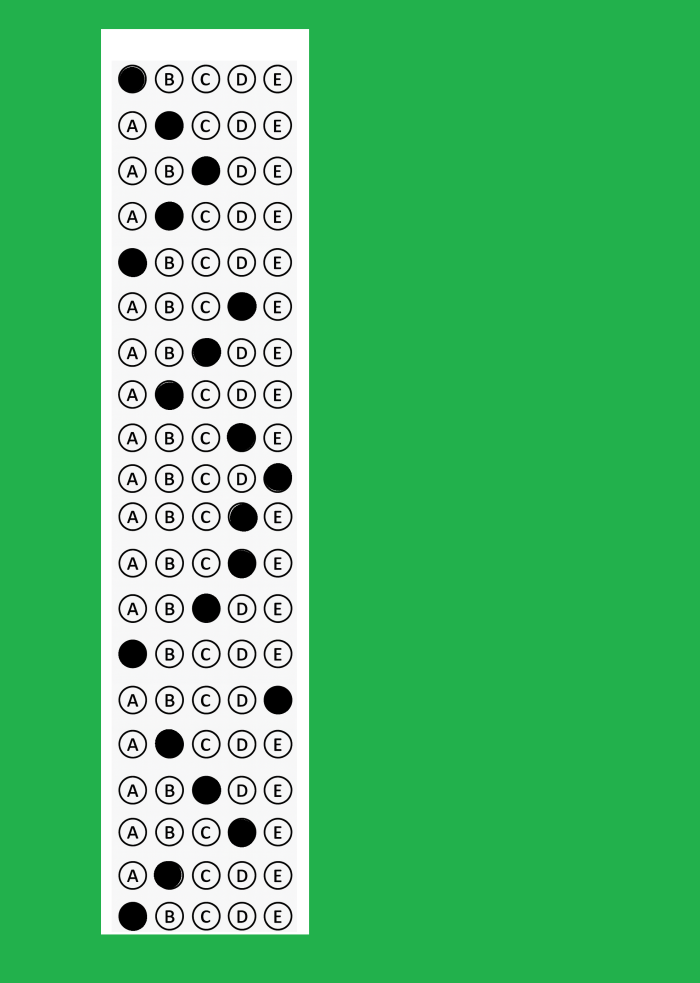

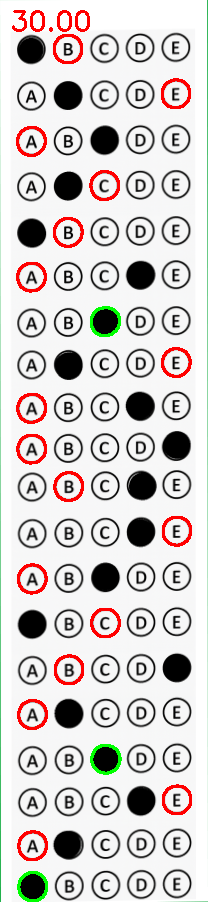

In [96]:
# calcular nota novamente (10 questões)
score = (correct / 10.0) * 100
print("[INFO] score: {:.2f}%".format(score))

# escreve a nota no canto superior da folha transformada
cv2.putText(
    paper,
    "{:.2f}".format(score),
    (10, 30),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.9,
    (0, 0, 255),
    2
)

# mostra imagens finais
cv2_imshow(image)
cv2_imshow(paper)
